In [87]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from pathlib import Path
import scipy
from scipy.ndimage import gaussian_filter1d

In [88]:
# load data
grad = xr.open_dataset('NC_average_lat_lon_with_gradient.nc')

In [89]:
# just for nobx
target_site = 'usa_NC_0032_0001'
start_idx = np.where(grad['site'].values == target_site)[0][0] + 200

rodanthe_site = 'usa_NC_0036_0027'
rodanthe_idx = np.where(grad['site'].values == rodanthe_site)[0][0] - start_idx

grad_nobx = grad.isel(site=slice(start_idx, None))

In [90]:
lrr = pd.read_csv('coastsat_lrr_obx_1984_2025.csv').set_index('transect_id')

d_eta = xr.Dataset(
    {'d_eta': ('site', lrr['lrr_m_yr'].reindex(grad_nobx['site'].values).values)},
    coords={
        'site': grad_nobx['site'].values,
        'lat': ('site', grad_nobx['lat'].values),
        'lon': ('site', grad_nobx['lon'].values),
    },
)

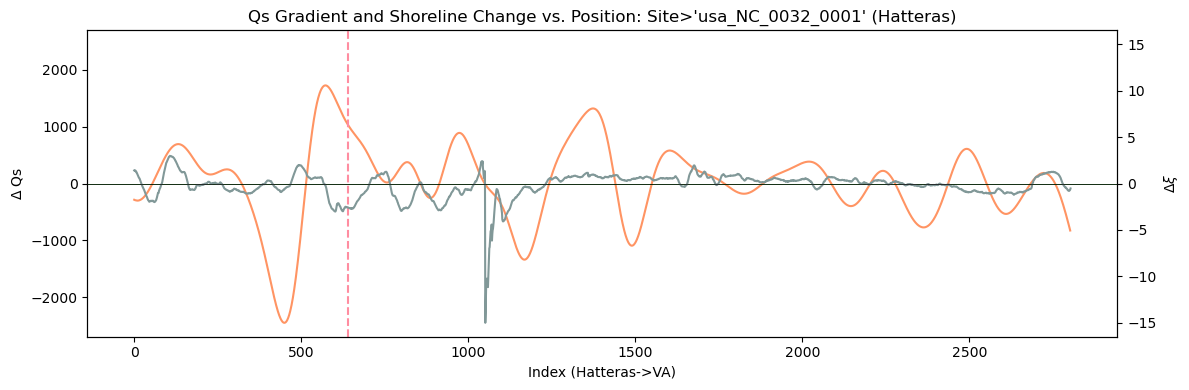

In [91]:
fig, ax = plt.subplots(figsize=(12, 4))
ax2 = ax.twinx()

l1, = ax.plot(grad_nobx['grad'].values, c='#FF9463', label=r'$\Delta$ Qs gradient')
l2, = ax2.plot(d_eta['d_eta'].values, c='#819898', label='Shoreline change (LRR)')
l3 = ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='g', lw=0.5)
ax2.axhline(0, color='k', lw=0.5)

lim1 = np.nanmax(np.abs(grad_nobx['grad'].values))*1.1
lim2 = np.nanmax(np.abs(d_eta['d_eta'].values))*1.1
ax.set_ylim(-lim1, lim1)
ax2.set_ylim(-lim2, lim2)

ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(r"$\Delta$ Qs", color='k')
ax2.set_ylabel(r"$\Delta \xi$", color='k')
ax.tick_params(axis='y', colors='k')
ax.set_title(f"Qs Gradient and Shoreline Change vs. Position: Site>'{target_site}' (Hatteras)")
plt.tight_layout()
plt.show()

In [92]:
d_eff = (grad_nobx['grad'] / d_eta['d_eta']).rename('d_eff')

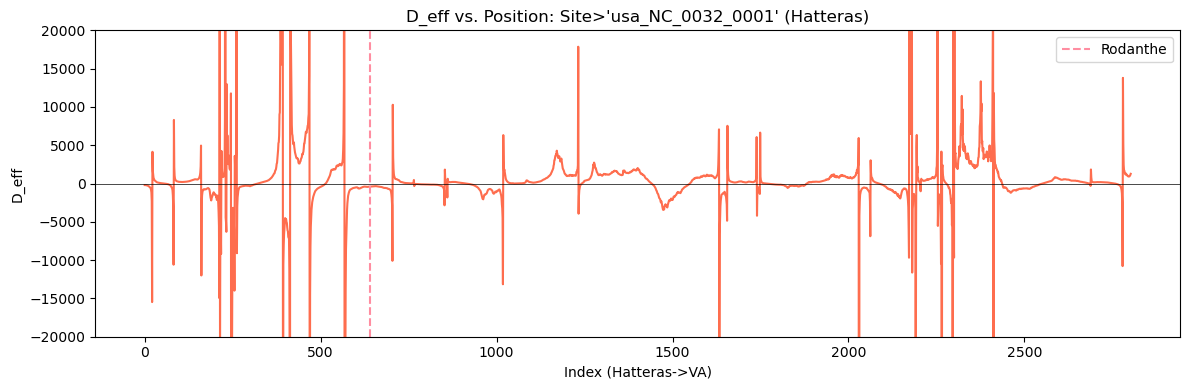

In [93]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff.values, color='#FE6D4E')
ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff")
ax.set_title(f"D_eff vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-20000,20000])
plt.tight_layout()
plt.legend()
plt.show()

In [94]:
d_eta_masked = d_eta['d_eta'].where(np.abs(d_eta['d_eta']) > .5)
d_eff_masked = (grad_nobx['grad'] / d_eta_masked).rename('d_eff')

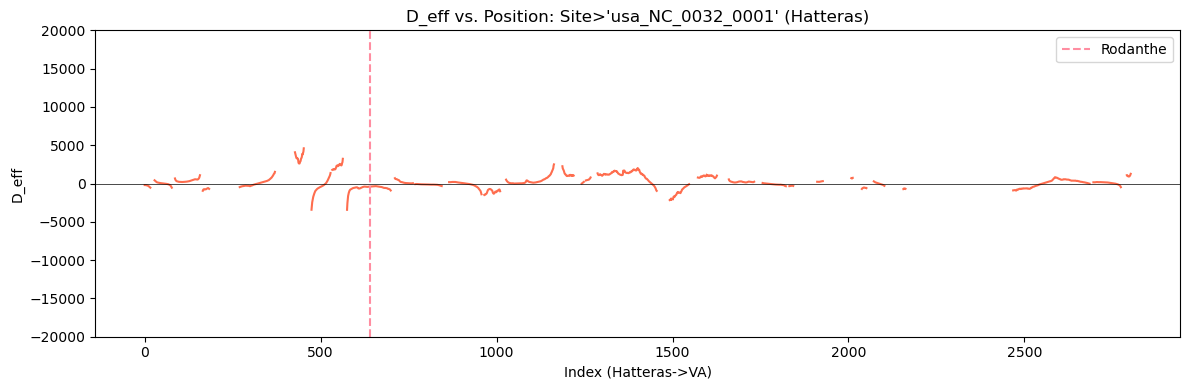

In [95]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff_masked.values, color='#FE6D4E')
ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff")
ax.set_title(f"D_eff vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-20000,20000])
plt.tight_layout()
plt.legend()
plt.show()

In [96]:
# cumulative along-shore distance (m) from d_eff's own lat/lon
lat_r = np.radians(d_eff_masked['lat'].values)
lon_r = np.radians(d_eff_masked['lon'].values)
a = (np.sin(np.diff(lat_r) / 2)**2
     + np.cos(lat_r[:-1]) * np.cos(lat_r[1:]) * np.sin(np.diff(lon_r) / 2)**2)
seg = 2 * 6371000.0 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
d_eff_masked = d_eff_masked.assign_coords(alongshore_m=('site', np.concatenate([[0.0], np.cumsum(seg)])))

# linear interpolation across gaps, but don't bridge gaps wider than max_gap meters
d_eff_interp = d_eff_masked.interpolate_na(dim='site', use_coordinate='alongshore_m', max_gap=10000)

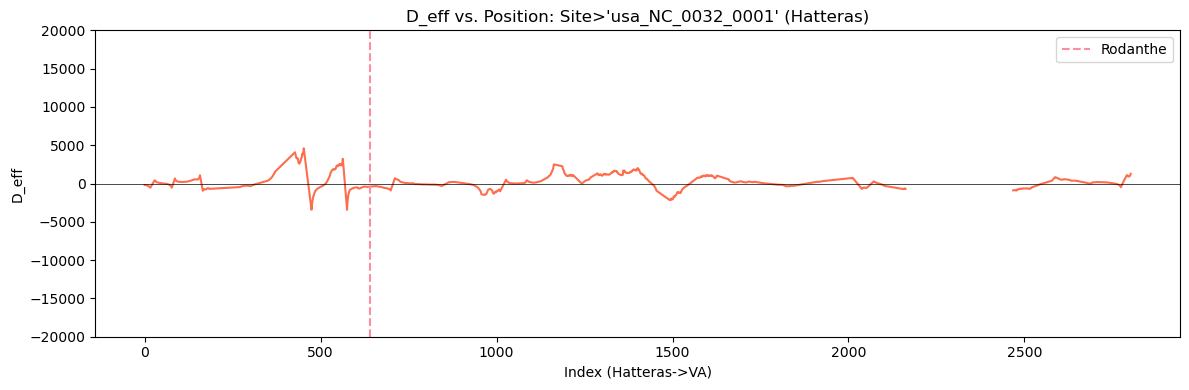

In [97]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff_interp.values, color='#FE6D4E')
ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff")
ax.set_title(f"D_eff vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-20000,20000])
plt.tight_layout()
plt.legend()
plt.show()

In [98]:
curv = xr.open_dataset('NC_average_lat_lon_with_curvature.nc')
diff = xr.open_dataset('ncmu_total_hourly_pertransect.nc', chunks={'time': 2000})
mean_diff = diff['mu'].mean(dim='time').compute()

/tmp/ipykernel_2685624/3423008418.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  diff = xr.open_dataset('ncmu_total_hourly_pertransect.nc', chunks={'time': 2000})


In [99]:
target_site = 'usa_NC_0032_0001'
start_idx = np.where(curv['site'].values == target_site)[0][0]+200

rodanthe_site = 'usa_NC_0036_0027'
rodanthe_idx = np.where(curv['site'].values == rodanthe_site)[0][0]-start_idx

curv_nobx = curv.isel(site=slice(start_idx, None))
mean_diff_nobx = mean_diff.isel(site=slice(start_idx, None))
diffusivity_nobx = mean_diff_nobx.values

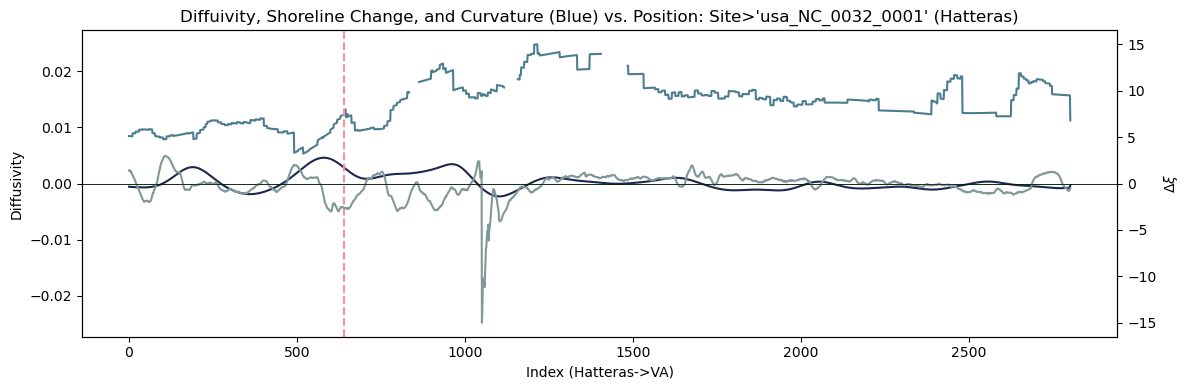

In [100]:
fig, ax = plt.subplots(figsize=(12, 4))
ax2 = ax.twinx()

l1, = ax.plot(diffusivity_nobx, c='#4C7D8E')
l2, = ax.plot(curv_nobx['curvature'].values*100, c='#1C284E')
l3, = ax2.plot(d_eta['d_eta'].values, c='#819898')
l4 = ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='g', lw=0.5)
ax2.axhline(0, color='k', lw=0.5)

lim1 = np.nanmax(np.abs(diffusivity_nobx))*1.1
lim2 = np.nanmax(np.abs(d_eta['d_eta'].values))*1.1
ax.set_ylim(-lim1, lim1)
ax2.set_ylim(-lim2, lim2)

ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel("Diffusivity", color='k')
ax2.set_ylabel(r"$\Delta \xi$", color='k')
ax.tick_params(axis='y', colors='k')
ax.set_title(f"Diffuivity, Shoreline Change, and Curvature (Blue) vs. Position: Site>'{target_site}' (Hatteras)")
plt.tight_layout()
plt.show()

In [101]:
d_eff2 = (mean_diff_nobx * (curv_nobx['curvature'] / d_eta['d_eta'])).rename('d_eff')

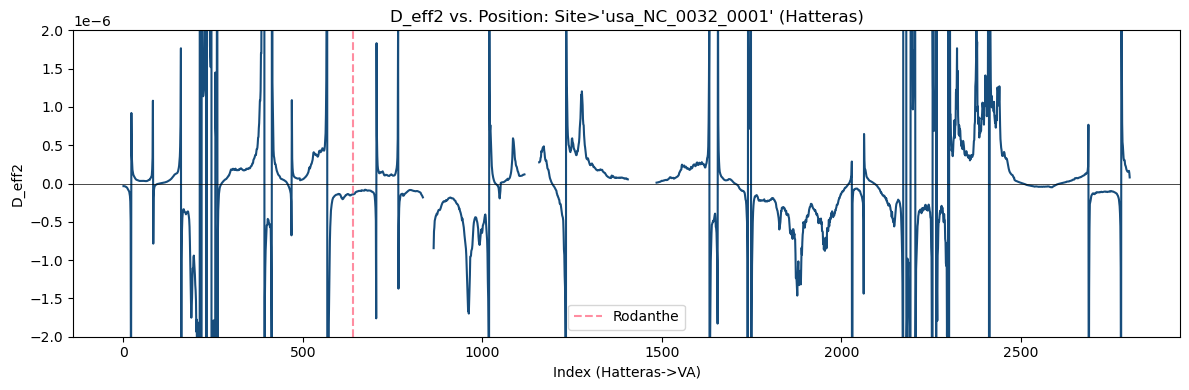

In [102]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff2.values, color='#174D7C')
ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff2")
ax.set_title(f"D_eff2 vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-.000002,.000002])
plt.tight_layout()
plt.legend()
plt.show()

In [103]:
d_eta_masked = d_eta['d_eta'].where(np.abs(d_eta['d_eta']) > .5)
d_eff2_masked = (mean_diff_nobx * (curv_nobx['curvature'] / d_eta_masked)).rename('d_eff')

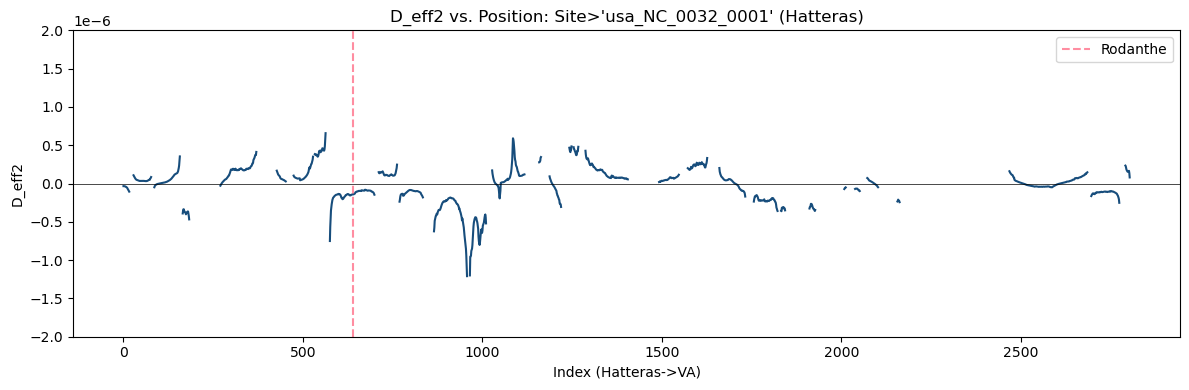

In [104]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff2_masked.values, color='#174D7C')
ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff2")
ax.set_title(f"D_eff2 vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-.000002,.000002])
plt.tight_layout()
plt.legend()
plt.show()

In [105]:
# cumulative along-shore distance (m) from d_eff's own lat/lon
lat_r = np.radians(d_eff2_masked['lat'].values)
lon_r = np.radians(d_eff2_masked['lon'].values)
a = (np.sin(np.diff(lat_r) / 2)**2
     + np.cos(lat_r[:-1]) * np.cos(lat_r[1:]) * np.sin(np.diff(lon_r) / 2)**2)
seg = 2 * 6371000.0 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
d_eff2_masked = d_eff2_masked.assign_coords(alongshore_m=('site', np.concatenate([[0.0], np.cumsum(seg)])))

# linear interpolation across gaps, but don't bridge gaps wider than max_gap meters
d_eff2_interp = d_eff2_masked.interpolate_na(dim='site', use_coordinate='alongshore_m', max_gap=10000)

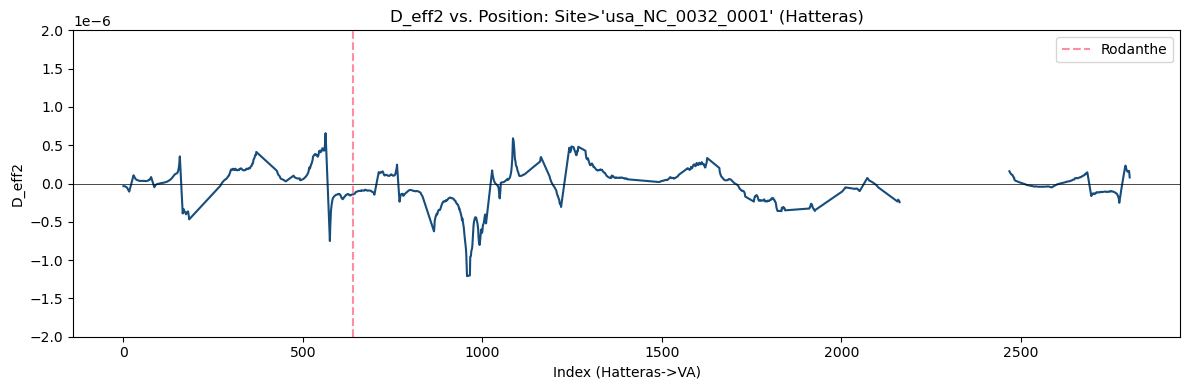

In [106]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff2_interp.values, color='#174D7C')
ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff2")
ax.set_title(f"D_eff2 vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-.000002,.000002])
plt.tight_layout()
plt.legend()
plt.show()

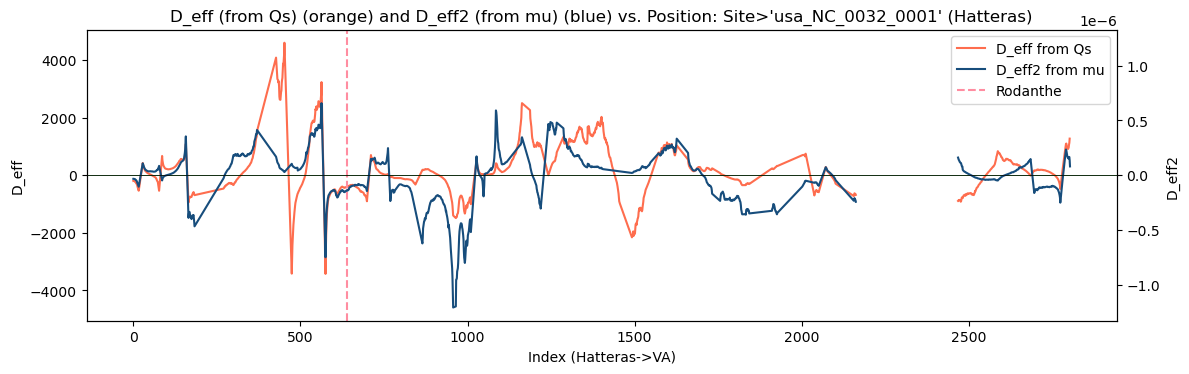

In [107]:
fig, ax = plt.subplots(figsize=(12, 4))
ax2 = ax.twinx()

l1, = ax.plot(d_eff_interp.values, color='#FE6D4E', label='D_eff from Qs')
l2, = ax2.plot(d_eff2_interp.values, color='#174D7C', label='D_eff2 from mu')
l3 = ax.axvline(x=rodanthe_idx, color='#FF8DA1', linestyle='--', label='Rodanthe')
ax.axhline(0, color='g', lw=0.5)
ax2.axhline(0, color='k', lw=0.5)

lim1 = np.nanmax(np.abs(d_eff_interp.values))*1.1
lim2 = np.nanmax(np.abs(d_eff2_interp.values))*1.1
ax.set_ylim(-lim1, lim1)
ax2.set_ylim(-lim2, lim2)

ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(r"D_eff", color='k')
ax2.set_ylabel(r"D_eff2", color='k')
ax.tick_params(axis='y', colors='k')
ax.set_title(f"D_eff (from Qs) (orange) and D_eff2 (from mu) (blue) vs. Position: Site>'{target_site}' (Hatteras)")
ax.legend(handles=[l1, l2, l3], loc='upper right')
plt.tight_layout()
plt.show()